## setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import matplotlib.pyplot as plt
import seaborn as sns
from src.extraction import load_processed
from src.clustering import kmeans_grid_search
import pandas as pd
import numpy as np

sys.path.append("..")
df_prepare_clustering = load_processed("df_prepare_clustering.csv")
df_prepare_clustering.shape

(8949, 7)

## run the grid search

In [2]:
grid_kmeans = kmeans_grid_search(df_prepare_clustering)
grid_kmeans.head(10)

,n_components,k,explained_variance,inertia,silhouette,min_cluster_pct,max_cluster_pct
0,2,3,0.646,13244.2,0.4487,27.1,37.9
1,2,2,0.646,23542.4,0.4310,31.3,68.7
2,2,4,0.646,10415.0,0.4217,19.3,30.8
3,2,5,0.646,8243.0,0.4101,15.6,27.7
4,3,6,0.760,11704.7,0.3986,5.8,23.3
5,2,7,0.646,5635.0,0.3979,11.0,19.8
6,2,6,0.646,6689.6,0.3947,11.9,27.0
7,3,5,0.760,13781.0,0.3909,15.8,24.2
8,3,4,0.760,16448.3,0.3888,20.9,27.9
9,3,3,0.760,20205.7,0.3826,26.7,39.9


## silhouette heatmap (components × k)

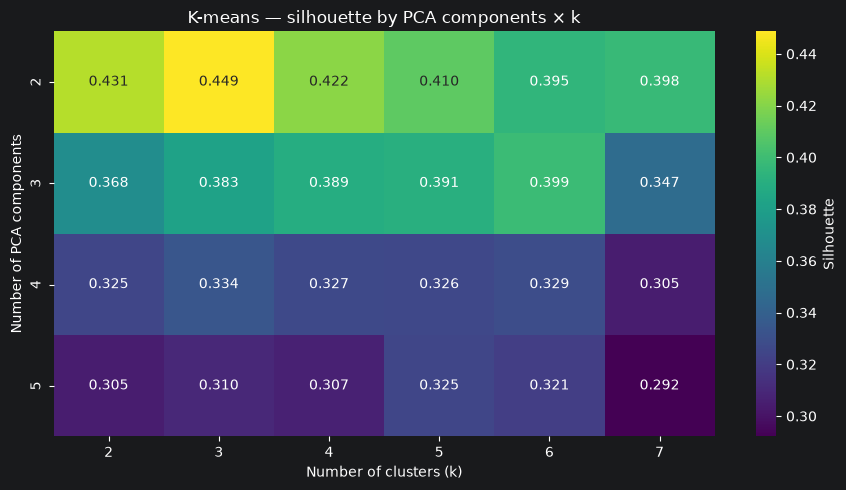

In [3]:
heatmap_data = grid_kmeans.pivot(index="n_components", columns="k", values="silhouette")

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis", cbar_kws={"label" : "Silhouette"})
plt.title("K-means — silhouette by PCA components × k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Number of PCA components")
plt.tight_layout()
plt.savefig("../reports/figures/03_kmeans_grid_heatmap.png", dpi=100)
plt.show()

## best combinations that are also balanced

In [4]:
balanced = grid_kmeans[grid_kmeans["min_cluster_pct"] >= 10]
balanced.head(5)


,n_components,k,explained_variance,inertia,silhouette,min_cluster_pct,max_cluster_pct
0,2,3,0.646,13244.2,0.4487,27.1,37.9
1,2,2,0.646,23542.4,0.4310,31.3,68.7
2,2,4,0.646,10415.0,0.4217,19.3,30.8
3,2,5,0.646,8243.0,0.4101,15.6,27.7
5,2,7,0.646,5635.0,0.3979,11.0,19.8
